In [1]:
from circuit_generation import low_depth_t_design,build_ansatz
import matplotlib.pyplot as plt

In [2]:
from frame_potential_gpu import compute_frame_potential_gpu
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector


In [3]:
from math import asin, acos
import numpy as np

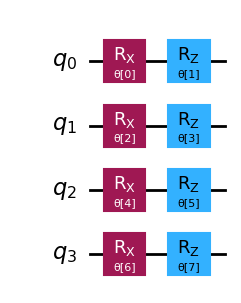

In [12]:
qc = build_ansatz(name="set", n_parameters=8, reps=1,number=1)
qc.draw("mpl")

In [ ]:
def parameter_composer(theta):
    for t in range(len(theta)):
        if t == 1:
            theta[t] = asin(theta[t]/np.pi-1)

In [ ]:
qc = QuantumCircuit(1)
params = ParameterVector('θ', 5)
qc.rz(params[0], 0)
qc.ry(params[1], 0)
qc.rx(params[2], 0)
F_p = compute_frame_potential_gpu(qc, t=2, n_samples=1000,verbose=False)
print("Frame potential (without parameter composer):", F_p["frame_potential"])
F_p = compute_frame_potential_gpu(qc, t=2, n_samples=1000, parameter_composer=parameter_composer, verbose=False)
print("Frame potential (with parameter composer):", F_p["frame_potential"])
F_p_3 = compute_frame_potential_gpu(qc, t=3, n_samples=10000, parameter_composer=parameter_composer, verbose=False)
print("Frame potential (t=3 with parameter composer):", F_p_3["frame_potential"])                                                                                                                                                                                                                                                                                                                                                                                                                          

F_p_4 = compute_frame_potential_gpu(qc, t=4, n_samples=10000, parameter_composer=parameter_composer, verbose=False)
print("Frame potential (t=4 with parameter composer):", F_p_4["frame_potential"])  

F_p_5 = compute_frame_potential_gpu(qc, t=5, n_samples=10000, parameter_composer=parameter_composer, verbose=False)
print("Frame potential (t=5 with parameter composer):", F_p_5["frame_potential"])



/home/tardant/Bureau/Qiskit/architectures/Frame potential/frame_potential_gpu.py:227: RuntimeWarning: Device does not support fp64; accumulating in float32.
  warnings.warn(


Frame potential (without parameter composer): 2.055328369140625
Frame potential (with parameter composer): 1.9977169036865234


/home/tardant/Bureau/Qiskit/architectures/Frame potential/frame_potential_gpu.py:292: UserWarning: d=2 < 2t=6: large-d approximation may be inaccurate.
  warnings.warn(f"d={d} < 2t={2*t}: large-d approximation may be inaccurate.")


Frame potential (t=3 with parameter composer): 4.999522686004639


/home/tardant/Bureau/Qiskit/architectures/Frame potential/frame_potential_gpu.py:292: UserWarning: d=2 < 2t=8: large-d approximation may be inaccurate.
  warnings.warn(f"d={d} < 2t={2*t}: large-d approximation may be inaccurate.")


Frame potential (t=4 with parameter composer): 14.002398490905762
Frame potential (t=5 with parameter composer): 42.01104736328125


/home/tardant/Bureau/Qiskit/architectures/Frame potential/frame_potential_gpu.py:292: UserWarning: d=2 < 2t=10: large-d approximation may be inaccurate.
  warnings.warn(f"d={d} < 2t={2*t}: large-d approximation may be inaccurate.")


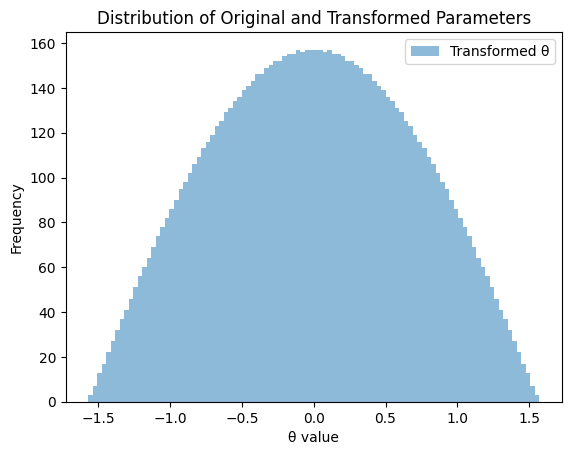

In [ ]:
X = np.linspace(0, 2*np.pi, 10000)
x = np.asin(X/np.pi-1)

plt.hist(x, bins=100, alpha=0.5, label='Transformed θ')
plt.legend()
plt.title("Distribution of Original and Transformed Parameters")
plt.xlabel("θ value")
plt.ylabel("Frequency")
plt.show()


In [ ]:
from save_read_results import build_result_table
import numpy as np

In [ ]:
L,var = build_result_table(path="data/results/classifier_results")


In [ ]:
L

[['real_amp',
  '1',
  'artificial_dataset',
  '2026-04-30 16:04:27.182656',
  'real_amp',
  '1',
  '0',
  '2',
  '500',
  '[1.1439078991689469, 0.827016516013242, 0.9104844676164187, 1.2972105432149323, 0.6958200765254402, 1.0950412857348686, 0.8558353108141219, 0.7037073093383936, 0.7001275985139821, 0.7162825383707384, 0.6728431901066925, 0.6516701029702462, 0.6397327934421037, 0.654054915678189, 0.6484644001868809, 0.6333599858049885, 0.6294696668708449, 0.6393081179146689, 0.6291700842508737, 0.623080740045129, 0.6196776367536774, 0.6219321949283855, 0.6260576820918978, 0.6211436543621958, 0.6240876025261798, 0.6195178602291452, 0.6215076910951187, 0.6215440556298829, 0.6215161676386128, 0.6201497026764774, 0.6235144853097689, 0.6214335944673296, 0.6209446051246225, 0.6229703099150481, 0.6228592190721011, 0.620755416996445, 0.6215613224850761, 0.6214540667599938, 0.6234400098496399, 0.6213977876809648, 0.6236402413666389, 0.6213937459136835, 0.6200371946632881, 0.6214711437736931,

In [ ]:
var

['anzats',
 'anzats_reps',
 'dataset_name',
 'date',
 'embeding',
 'embeding_reps',
 'layer_reps',
 'number_of_qubits',
 'number_of_samples',
 'objective_func_vals',
 'optimizer',
 'seed',
 'test_score',
 'trainging_time',
 'training_score']

In [ ]:
anzats_total_rep = []
for i in range(len(L)):
    anzats_total_rep.append(int(L[i][1]) * (int(L[i][6])+1))

score = []
for i in range(len(L)):
    score.append(float(L[i][12]))

layers = []
for i in range(len(L)):
    layers.append(int(L[i][6])+1)

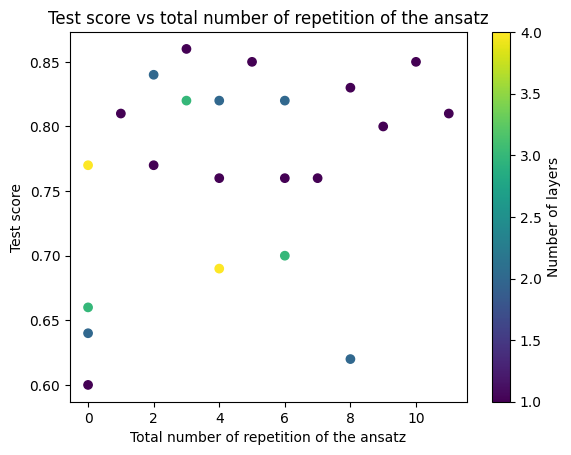

In [ ]:
plt.scatter(anzats_total_rep, score , c=layers, cmap="viridis")
plt.xlabel("Total number of repetition of the ansatz")
plt.ylabel("Test score")
plt.colorbar(label="Number of layers")
plt.title("Test score vs total number of repetition of the ansatz")
plt.show()

In [ ]:
import pandas as pd
from matplotlib.patches import Patch
from matplotlib import cm


In [ ]:
F,var = build_result_table(path="data/results/frame_potential")


In [ ]:
var

['circuit_depth',
 'd',
 'delta',
 'device',
 'dtype',
 'fidelity_error',
 'frame_potential',
 'haar_value',
 'n_parameters',
 'n_qubits',
 'n_samples',
 'name',
 'ratio',
 'reps',
 't',
 'variance']

In [ ]:
# get F and the var in a pandas dataframe
df = pd.DataFrame(F, columns=var)
# split the name column to get the number of the ansat and change it to int
df = df[df["name"].str.contains("set")]
df = df[df["n_qubits"] == '8']
df["name"] = df["name"].apply(lambda x: x.split("_")[1])
df["name"] = df["name"].astype(int)
# change the type of the var column to int
df["n_parameters"] = df["n_parameters"].astype(int)
df["circuit_depth"] = df["circuit_depth"].astype(int)
df["n_qubits"] = df["n_qubits"].astype(int)
df["frame_potential"] = df["frame_potential"].astype(float)
df.head()

,circuit_depth,d,delta,device,dtype,fidelity_error,frame_potential,haar_value,n_parameters,n_qubits,n_samples,name,ratio,reps,t,variance
0,31,256,1.9977490901947021,xpu,torch.complex64,0.057980177940477697,3.997749,2.0,64,8,512,13,1.998874545097351,2,2,881.249755859375
2,6,256,10026.1484375,xpu,torch.complex64,2582.5514515687773,10032.148438,6.0,39,8,768,7,1672.0247395833333,1,3,3933873635328.0
5,9,256,253.81796264648438,xpu,torch.complex64,4.937642155785872,254.817963,1.0,8,8,256,10,254.81796264648438,1,1,1597788.0
6,73,256,0.5601615905761719,xpu,torch.complex64,0.025715560971824255,2.560162,2.0,93,8,512,19,1.280080795288086,4,2,173.3532257080078
7,21,256,0.36631011962890625,xpu,torch.complex64,0.021293683190406455,2.366310,2.0,64,8,512,2,1.1831550598144531,4,2,118.86157989501953


In [ ]:
df_t1 = df[df["t"] == '1']
fp_objectif = 1
df_t1["frame_potential"] = abs(df_t1["frame_potential"] - fp_objectif)
df_t2 = df[df["t"] == '2']
fp_objectif = 2
df_t2["frame_potential"] = abs(df_t2["frame_potential"] - fp_objectif)
df_t3 = df[df["t"] == '3']
fp_objectif = 6
df_t3["frame_potential"] = abs(df_t3["frame_potential"] - fp_objectif)
df_t1.head()

,circuit_depth,d,delta,device,dtype,fidelity_error,frame_potential,haar_value,n_parameters,n_qubits,n_samples,name,ratio,reps,t,variance
5,9,256,253.81796264648438,xpu,torch.complex64,4.937642155785872,253.817963,1.0,8,8,256,10,254.81796264648438,1,1,1597788.0
8,18,256,0.005869865417480469,xpu,torch.complex64,0.005234646479606536,0.005870,1.0,80,8,256,11,1.0058698654174805,3,1,1.7957862615585327
14,2,256,0.00040602684020996094,xpu,torch.complex64,0.12576603856719562,0.000406,1.0,16,8,256,1,1.00040602684021,1,1,1036.5892333984375
16,6,256,0.11217021942138672,xpu,torch.complex64,0.08180974390911443,0.112170,1.0,48,8,256,1,1.1121702194213867,3,1,438.62158203125
20,501,256,0.004468202590942383,xpu,torch.complex64,0.003932032167498702,0.004468,1.0,324,8,256,6,1.0044682025909424,4,1,1.0132440328598022


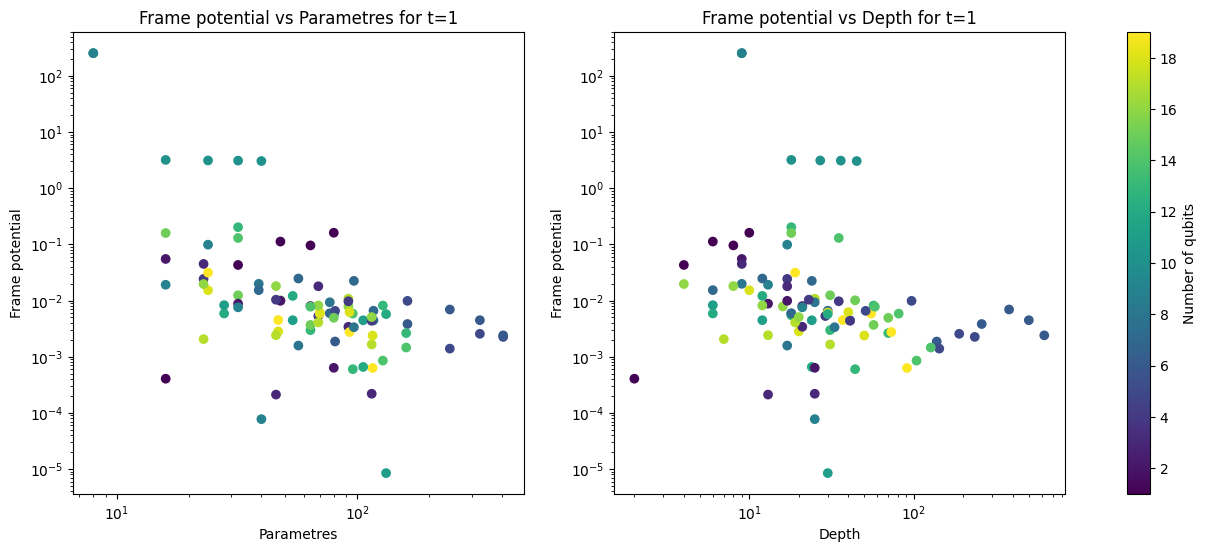

In [ ]:
# plot the frame_potential depending on the parameters collored but the name of the ansatz
# use only the values where t = 1
df_to_plot = df_t1
# do 2 subplots one for the plot depending on the parameter the other for the plot depending on the depth
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.set_yscale('log')
ax1.set_xscale('log')

# do a log plot of the frame potential depending on the parameters collored but the name of the ansatz
ax1.scatter(df_to_plot["n_parameters"],df_to_plot["frame_potential"],c=df_to_plot["name"], cmap="viridis")
ax1.set_xlabel("Parametres")
ax1.set_ylabel("Frame potential")
ax1.set_title("Frame potential vs Parametres for t=1")


ax2.set_yscale('log')
ax2.set_xscale('log')

scatter2 = ax2.scatter(df_to_plot["circuit_depth"],df_to_plot["frame_potential"],c=df_to_plot["name"], cmap="viridis")
ax2.set_xlabel("Depth")
ax2.set_ylabel("Frame potential")
ax2.set_title("Frame potential vs Depth for t=1")
fig.colorbar(scatter2, label="Number of qubits", ax=[ax1, ax2])

plt.show()

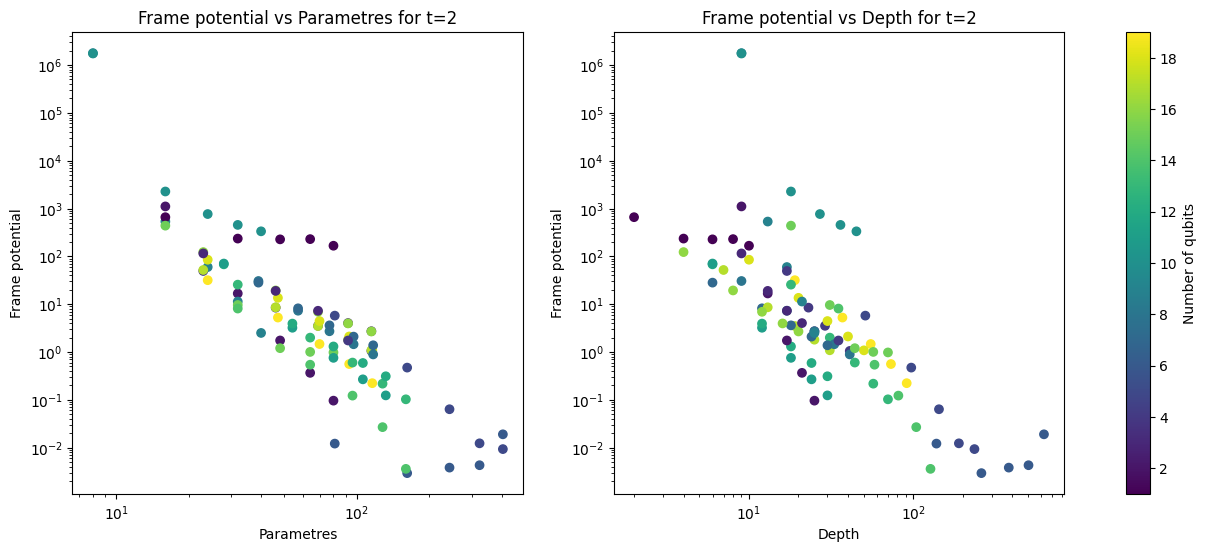

In [ ]:
# plot the frame_potential depending on the parameters collored but the name of the ansatz
# use only the values where t = 1
df_to_plot = df_t2
# do 2 subplots one for the plot depending on the parameter the other for the plot depending on the depth
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.set_yscale('log')
ax1.set_xscale('log')

# do a log plot of the frame potential depending on the parameters collored but the name of the ansatz
ax1.scatter(df_to_plot["n_parameters"],df_to_plot["frame_potential"],c=df_to_plot["name"], cmap="viridis")
ax1.set_xlabel("Parametres")
ax1.set_ylabel("Frame potential")
ax1.set_title("Frame potential vs Parametres for t=2")


ax2.set_yscale('log')
ax2.set_xscale('log')

scatter2 = ax2.scatter(df_to_plot["circuit_depth"],df_to_plot["frame_potential"],c=df_to_plot["name"], cmap="viridis")
ax2.set_xlabel("Depth")
ax2.set_ylabel("Frame potential")
ax2.set_title("Frame potential vs Depth for t=2")
fig.colorbar(scatter2, label="Number of qubits", ax=[ax1, ax2])

plt.show()

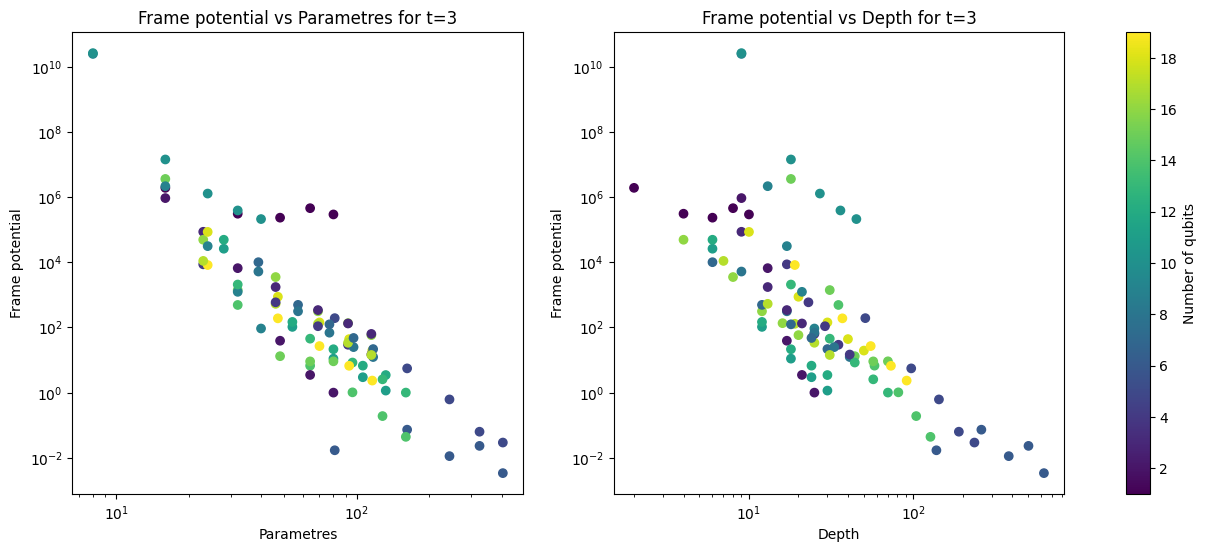

In [ ]:
# plot the frame_potential depending on the parameters collored but the name of the ansatz
# use only the values where t = 1
df_to_plot = df_t3
# do 2 subplots one for the plot depending on the parameter the other for the plot depending on the depth
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.set_yscale('log')
ax1.set_xscale('log')

# do a log plot of the frame potential depending on the parameters collored but the name of the ansatz
ax1.scatter(df_to_plot["n_parameters"],df_to_plot["frame_potential"],c=df_to_plot["name"], cmap="viridis")
ax1.set_xlabel("Parametres")
ax1.set_ylabel("Frame potential")
ax1.set_title("Frame potential vs Parametres for t=3")


ax2.set_yscale('log')
ax2.set_xscale('log')

scatter2 = ax2.scatter(df_to_plot["circuit_depth"],df_to_plot["frame_potential"],c=df_to_plot["name"], cmap="viridis")
ax2.set_xlabel("Depth")
ax2.set_ylabel("Frame potential")
ax2.set_title("Frame potential vs Depth for t=3")
fig.colorbar(scatter2, label="Number of qubits", ax=[ax1, ax2])

plt.show()

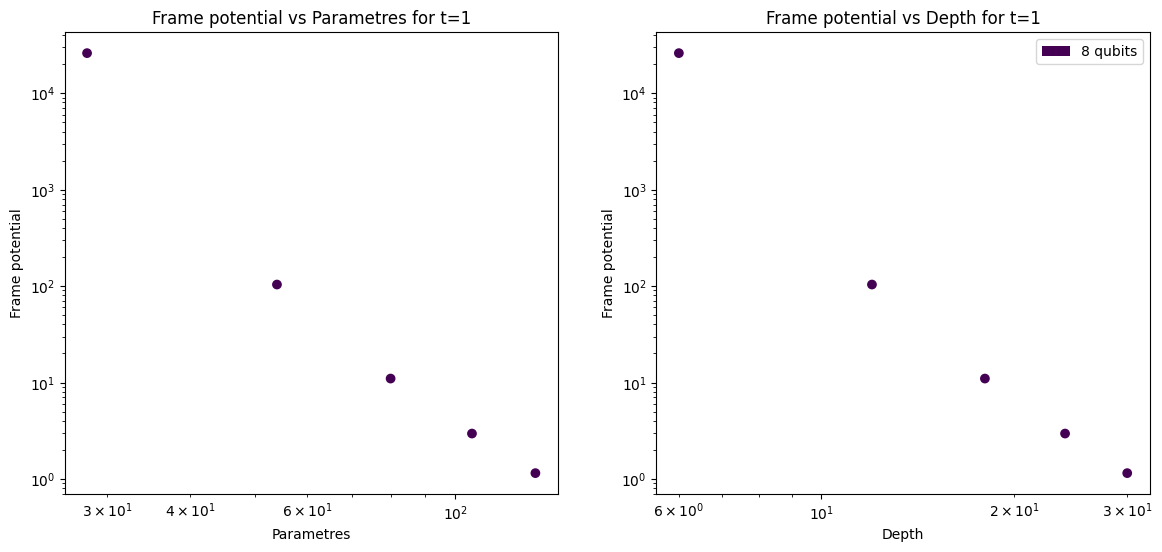

In [ ]:



df_to_plot = df_t3[df_t3["name"] == 11]

# do 2 subplots one for the plot depending on the parameter the other for the plot depending on the depth
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.set_yscale('log')
ax1.set_xscale('log')

# do a log plot of the frame potential depending on the parameters collored but the name of the ansatz
ax1.scatter(df_to_plot["n_parameters"],df_to_plot["frame_potential"],c=df_to_plot["n_qubits"], cmap="viridis")
ax1.set_xlabel("Parametres")
ax1.set_ylabel("Frame potential")
ax1.set_title("Frame potential vs Parametres for t=1")


ax2.set_yscale('log')
ax2.set_xscale('log')

scatter2 = ax2.scatter(df_to_plot["circuit_depth"],df_to_plot["frame_potential"],c=df_to_plot["n_qubits"], cmap="viridis")
ax2.set_xlabel("Depth")
ax2.set_ylabel("Frame potential")
ax2.set_title("Frame potential vs Depth for t=1")

unique_vals = sorted(df_to_plot["n_qubits"].unique())
colors = cm.viridis(np.linspace(0, 1, len(unique_vals)))
legend_elements = [Patch(facecolor=colors[i], label=f"{int(val)} qubits") 
                   for i, val in enumerate(unique_vals)]
ax2.legend(handles=legend_elements, loc='best')
plt.show()